# 06. Advanced Model Development (Ensemble Models)

**Objective:**  
Train ensemble-based classifiers to improve performance over baseline models
using feature-engineered landmark data.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
TRAIN_PATH = Path("../data/train_fe.csv")
TEST_PATH  = Path("../data/test_fe.csv")

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

X_train = train_df.drop(columns=["class"])
y_train = train_df["class"]

X_test = test_df.drop(columns=["class"])
y_test = test_df["class"]

print("✅ Feature-engineered data loaded")
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


✅ Feature-engineered data loaded
Train shape: (13130, 47)
Test shape : (3283, 47)


In [3]:
print("📊 Class distribution:")
print(y_train.value_counts().sort_index())

# Balanced class weights for ensemble model
class_weights = "balanced"
print("✅ Class imbalance handled using class_weight='balanced'")


📊 Class distribution:
class
0     666
1     677
2     449
3     687
4     586
5     651
6     354
7     534
8     712
9     586
10    273
11    690
12    678
13    500
14    638
15    593
16    675
17    698
18    510
19    694
20    709
21    570
Name: count, dtype: int64
✅ Class imbalance handled using class_weight='balanced'


In [4]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight=class_weights,
    n_jobs=-1
)

print("🚀 Training Random Forest model...")
rf_model.fit(X_train, y_train)


🚀 Training Random Forest model...


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
rf_pred = rf_model.predict(X_test)

print("📋 Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))


📋 Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       166
           1       0.98      0.99      0.99       169
           2       0.99      0.97      0.98       112
           3       1.00      1.00      1.00       172
           4       0.99      1.00      1.00       146
           5       1.00      0.99      1.00       163
           6       0.98      0.99      0.98        88
           7       1.00      0.99      0.99       134
           8       1.00      1.00      1.00       178
           9       1.00      1.00      1.00       147
          10       0.96      0.99      0.97        68
          11       0.99      0.99      0.99       173
          12       0.98      0.98      0.98       169
          13       0.99      0.98      0.98       125
          14       1.00      0.99      1.00       159
          15       1.00      0.99      1.00       148
          16       0.99      1.00      1.0

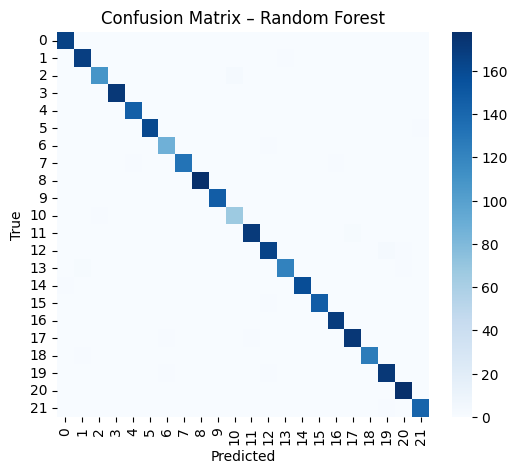

📊 Confusion matrix plotted for Random Forest


In [6]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix – Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("📊 Confusion matrix plotted for Random Forest")


In [7]:
import joblib

MODEL_DIR = Path("../models/advanced")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(rf_model, MODEL_DIR / "random_forest.pkl")

print("✅ Random Forest model saved for comparison")


✅ Random Forest model saved for comparison
